In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Loading the dataset
df = pd.read_excel('../data/raw/Coffee Shop Sales.xlsx')

# First look at the data
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset shape: 149116 rows x 11 columns

First 5 rows:


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [3]:
# Understanding the dataset structure
print("Column names and data types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())

Column names and data types:
transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

Missing values per column:
transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


In [4]:
# Creating revenue column
df['revenue'] = df['transaction_qty'] * df['unit_price']

# General statistics
print("=== GENERAL OVERVIEW ===")
print(f"Total transactions: {df['transaction_id'].nunique():,}")
print(f"Total revenue: $ {df['revenue'].sum():,.2f}")
print(f"Average ticket: $ {df['revenue'].mean():,.2f}")
print(f"Period: {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")
print(f"\nStore locations: {df['store_location'].unique()}")
print(f"Product categories: {df['product_category'].unique()}")

=== GENERAL OVERVIEW ===
Total transactions: 149,116
Total revenue: $ 698,812.33
Average ticket: $ 4.69
Period: 2023-01-01 to 2023-06-30

Store locations: ['Lower Manhattan' "Hell's Kitchen" 'Astoria']
Product categories: ['Coffee' 'Tea' 'Drinking Chocolate' 'Bakery' 'Flavours' 'Loose Tea'
 'Coffee beans' 'Packaged Chocolate' 'Branded']


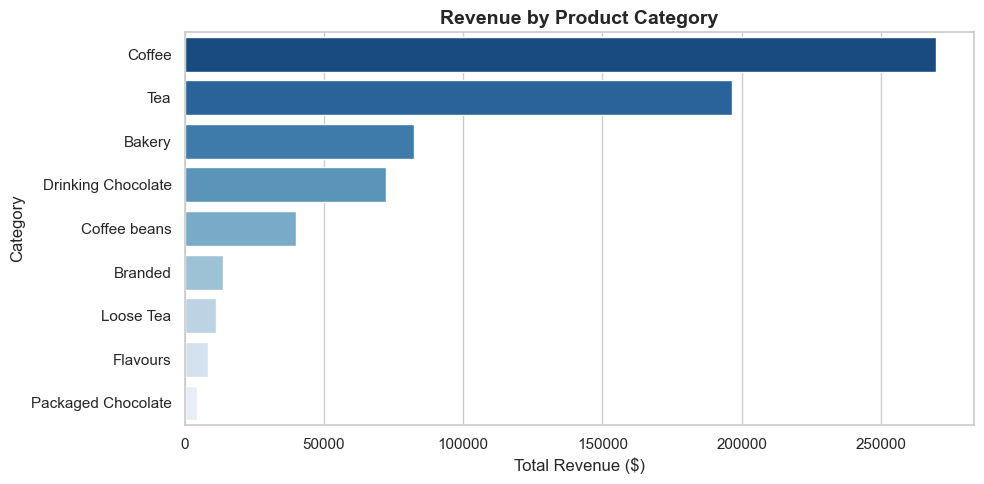

     product_category    revenue
0              Coffee  269952.45
1                 Tea  196405.95
2              Bakery   82315.64
3  Drinking Chocolate   72416.00
4        Coffee beans   40085.25
5             Branded   13607.00
6           Loose Tea   11213.60
7            Flavours    8408.80
8  Packaged Chocolate    4407.64


In [5]:
# Revenue by product category
category_revenue = (df.groupby('product_category')['revenue']
                    .sum()
                    .sort_values(ascending=False)
                    .reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=category_revenue, x='revenue', y='product_category', hue='product_category', palette='Blues_r', legend=False)
plt.title('Revenue by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('../data/processed/revenue_by_category.png', dpi=150)
plt.show()
print(category_revenue)

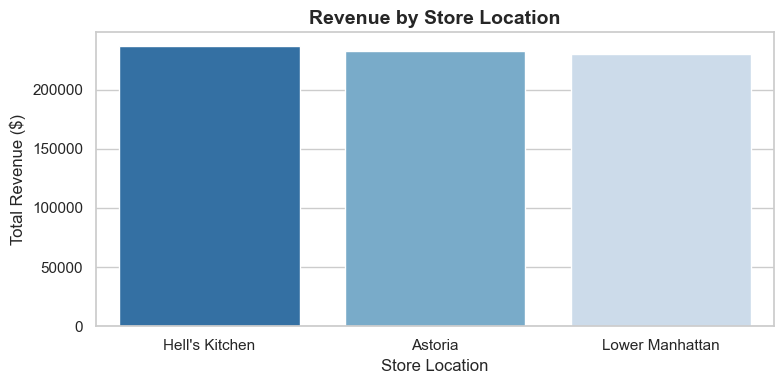

    store_location    revenue
0   Hell's Kitchen  236511.17
1          Astoria  232243.91
2  Lower Manhattan  230057.25


In [6]:
# Revenue by store location
store_revenue = (df.groupby('store_location')['revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index())

plt.figure(figsize=(8, 4))
sns.barplot(data=store_revenue, x='store_location', y='revenue', hue='store_location', palette='Blues_r', legend=False)
plt.title('Revenue by Store Location', fontsize=14, fontweight='bold')
plt.xlabel('Store Location')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('../data/processed/revenue_by_store.png', dpi=150)
plt.show()
print(store_revenue)

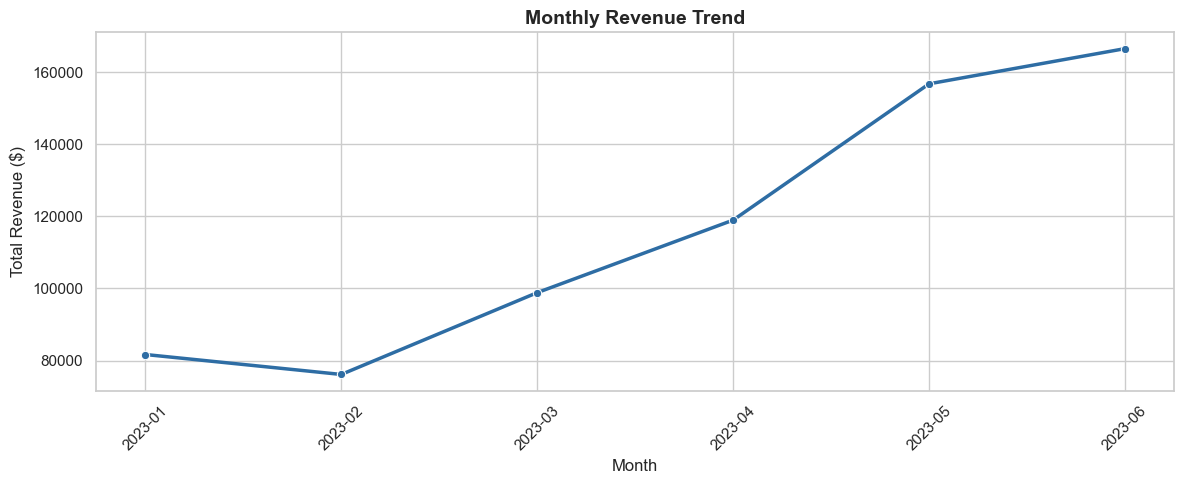

     month    revenue
0  2023-01   81677.74
1  2023-02   76145.19
2  2023-03   98834.68
3  2023-04  118941.08
4  2023-05  156727.76
5  2023-06  166485.88


In [7]:
# Monthly revenue trend
df['month'] = df['transaction_date'].dt.to_period('M')
monthly_revenue = (df.groupby('month')['revenue']
                   .sum()
                   .reset_index())
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_revenue, x='month', y='revenue', marker='o', color='#2E6DA4', linewidth=2.5)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/monthly_trend.png', dpi=150)
plt.show()
print(monthly_revenue)

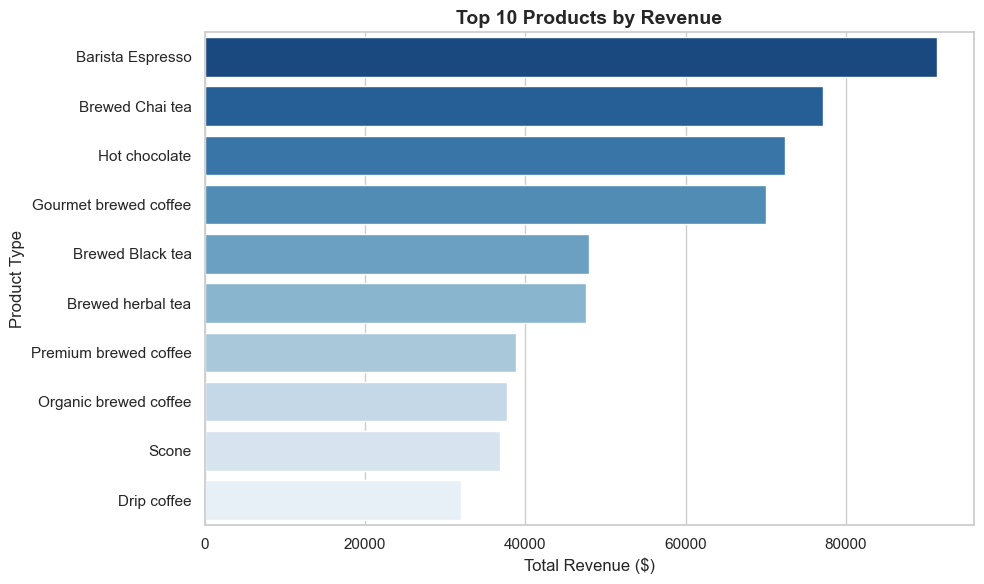

In [8]:
# Top 10 products by revenue
top_products = (df.groupby('product_type')['revenue']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='revenue', y='product_type', hue='product_type', palette='Blues_r', legend=False)
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Type')
plt.tight_layout()
plt.savefig('../data/processed/top_products.png', dpi=150)
plt.show()

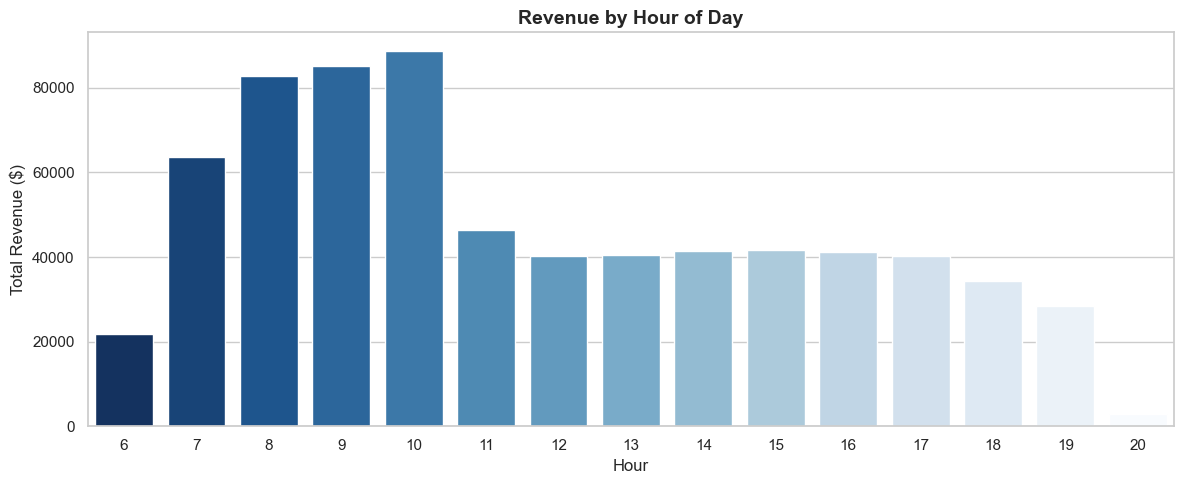

In [11]:
# Sales by hour of day
df['hour'] = df['transaction_time'].apply(lambda x: x.hour)

hourly_sales = (df.groupby('hour')['revenue']
                .sum()
                .reset_index())

plt.figure(figsize=(12, 5))
sns.barplot(data=hourly_sales, x='hour', y='revenue', hue='hour', palette='Blues_r', legend=False)
plt.title('Revenue by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('../data/processed/revenue_by_hour.png', dpi=150)
plt.show()

In [12]:
# Key insights summary
top_category = category_revenue.iloc[0]
top_store = store_revenue.iloc[0]
top_product = top_products.iloc[0]
peak_hour = hourly_sales.loc[hourly_sales['revenue'].idxmax(), 'hour']

print("=" * 50)
print("KEY BUSINESS INSIGHTS")
print("=" * 50)
print(f"""
OVERVIEW
- Period analyzed: Jan 2023 to Jun 2023
- Total transactions: 149,116
- Total revenue: $698,812.33
- Average ticket: $4.69

TOP PERFORMERS
- Best category:  {top_category['product_category']} 
                  ($ {top_category['revenue']:,.2f})
- Best store:     {top_store['store_location']} 
                  ($ {top_store['revenue']:,.2f})
- Best product:   {top_product['product_type']} 
                  ($ {top_product['revenue']:,.2f})

PEAK HOURS
- Highest revenue hour: {peak_hour}:00h

RECOMMENDATIONS
- Focus marketing efforts during peak hours
- Replicate best store practices across locations
- Expand top product availability in underperforming stores
""")

KEY BUSINESS INSIGHTS

OVERVIEW
- Period analyzed: Jan 2023 to Jun 2023
- Total transactions: 149,116
- Total revenue: $698,812.33
- Average ticket: $4.69

TOP PERFORMERS
- Best category:  Coffee 
                  ($ 269,952.45)
- Best store:     Hell's Kitchen 
                  ($ 236,511.17)
- Best product:   Barista Espresso 
                  ($ 91,406.20)

PEAK HOURS
- Highest revenue hour: 10:00h

RECOMMENDATIONS
- Focus marketing efforts during peak hours
- Replicate best store practices across locations
- Expand top product availability in underperforming stores

